In [1]:
import sys
import pandas as pd
import sqlite3 as sq3
import enum
import numpy as np
from scipy.signal import savgol_filter
from pathlib import Path

cwd = Path.cwd()
sys.path.append(str(cwd.parent))
import strategies_v2 as strategy

class POSITION(enum.Enum):
    NEUTRAL = 0
    LONG = 1
    SHORT = -1
    
class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL_EMA = 0
    PRICE_ACCION_OVER_EMA = 1
    PRICE_ACCION_UNDER_EMA = 2

if __name__ == '__main__':
    
    df = pd.read_csv("../../../backtesting/data/EURUSD/EURUSD_Candlestick_5_M_ASK_30.10.2023-30.10.2024.csv")

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    est=pd.to_datetime(df["Gmt time"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

    fromTodayStart = '2024-04-01 09:30:00'
    toNow   = '2024-04-15 16:00:00'
    df = df[est.between(fromTodayStart, toNow)].copy()

    df.rename(columns={"Open": "open"}, inplace=True)
    df.rename(columns={"High": "high"}, inplace=True)
    df.rename(columns={"Low": "low"}, inplace=True)
    df.rename(columns={"Volume": "volume"}, inplace=True)
    df.rename(columns={"Close": "close"}, inplace=True)
    df.rename(columns={"Gmt time": "time"}, inplace=True)

    df=df[df.notnull().all(axis=1)]
    df=df[(df.volume != 0)]
    df=df[df.high!=df.low]
    
    df.reset_index(drop=True, inplace=True)
    df['bar']=df.index
    
    df.set_index("time", inplace=True, drop=True)
    df = df[['bar','high','low','close','volume','open']] 

    result = strategy.squeez(df).copy()
    #print(result)
    
    result.to_csv('backtest_result.csv', index=False)
    #conn = sq3.connect('squeez_rawdata_v2.sql') 
    #result.to_sql('data', conn, if_exists='append')

In [4]:
def positionArea(x):
    extraSpace = .020
    low = round(x['low']*10,4)
    high = round(x['high']*10,4)
    
    if (x['position']==POSITION['LONG'].value):
        return low-extraSpace
    elif (x['position']==POSITION['SHORT'].value):
        return high+extraSpace    
    else:
        return np.nan
        
def posibleEntryArea(x):
    extraSpace = .015
    low = round(x['low']*10,4)
    high = round(x['high']*10,4)
    
    if (x['posible_entry']==POSITION['LONG'].value):
        return low-extraSpace
    elif (x['posible_entry']==POSITION['SHORT'].value):
        return high+extraSpace    
    else:
        return np.nan
                
def squeezeCloseToEmaArea(x):
    extraSpace = .010
    low = round(x['low']*10,4)
    high = round(x['high']*10,4)
    
    if (x['squeeze_close_ema']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return low-extraSpace
    elif (x['squeeze_close_ema']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return high+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .005
    low = round(x['low']*10,4)
    high = round(x['high']*10,4)
    
    if (x['squeezed_area']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return low-extraSpace
    elif (x['squeezed_area']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return high+extraSpace
    else:
        return np.nan
        
with pd.option_context("mode.copy_on_write", True): 
    result['squezzeArea'] = result.apply(lambda row: squezzeArea(row), axis=1)
    result['squeezeCloseToEmaArea'] = result.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
    result['posibleEntry'] = result.apply(lambda row: posibleEntryArea(row), axis=1)
    result['positionArea'] = result.apply(lambda row: positionArea(row), axis=1)

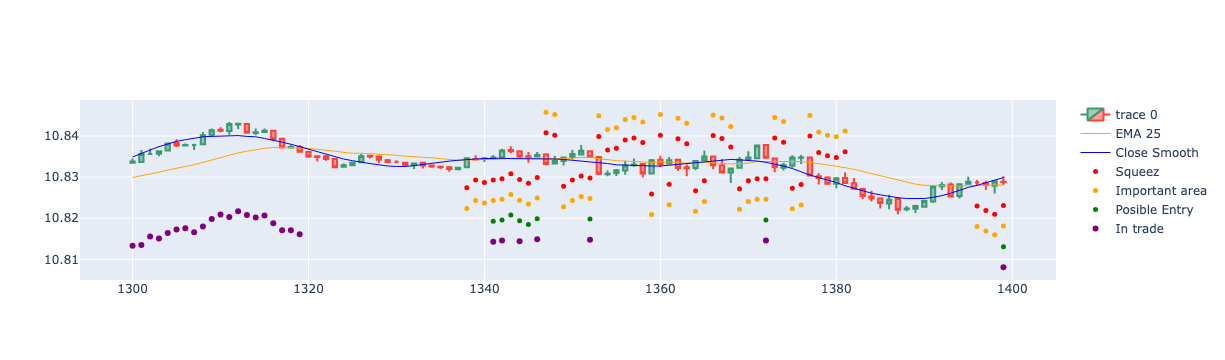

In [17]:
import plotly.graph_objects as go  
import plotly.express as px

dfpl = result[1300:1400]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl['bar'], 
            open=round(dfpl['open']*10,4),
            high=round(dfpl['high']*10,4),
            low=round(dfpl['low']*10,4),
            close=round(dfpl['close']*10,4)
        ),
        go.Scatter(
            x=dfpl['bar'], 
            y=round(dfpl['ema25']*10,4),
            line=dict(color='orange', width=1), 
            name="EMA 25"),
        go.Scatter(
            x=dfpl['bar'], 
            y=round(dfpl['close_smooth']*10,4),
            line=dict(color='blue', width=1), 
            name="Close Smooth")
    ]
)

fig.add_scatter(x=dfpl['bar'], y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl['bar'], y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl['bar'], y=dfpl['posibleEntry'], mode="markers", marker=dict(size=5, color="green"), name="Posible Entry")
fig.add_scatter(x=dfpl['bar'], y=dfpl['positionArea'], mode="markers", marker=dict(size=6, color="purple"), name="In trade")

fig.update_layout(
    xaxis_rangeslider_visible=False
)

fig.show()